In [1]:
import os, sys
from pathlib import Path
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [2]:
import os
from pathlib import Path

# ---------- 1) Stop any existing SparkSession (if any) ----------
try:
    spark.stop()
    print("Stopped existing SparkSession.")
except Exception:
    print("No SparkSession to stop (ok).")

# ---------- 2) Clear PySpark global state (fixes dead Py4J gateway) ----------
try:
    from pyspark.context import SparkContext
    from pyspark.sql import SparkSession

    for k in ["PYSPARK_GATEWAY_PORT", "PYSPARK_GATEWAY_SECRET"]:
        if k in os.environ:
            os.environ.pop(k, None)
            print(f"Cleared env {k}")

    SparkContext._active_spark_context = None
    SparkContext._gateway = None
    SparkContext._jvm = None

    try:
        SparkSession._instantiatedContext = None
        SparkSession._activeSession = None
        SparkSession._defaultSession = None
    except Exception:
        pass

    print("✅ PySpark internals reset")
except Exception as e:
    print("⚠️ Reset step warning:", type(e).__name__, e)

# ---------- 3) Start Spark (stable local mode) ----------
from pyspark.sql import SparkSession

OUTPUT_ROOT = Path.home() / "opendota_processed"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SPARK_LOCAL_DIR = OUTPUT_ROOT / "spark_local"
SPARK_LOCAL_DIR.mkdir(parents=True, exist_ok=True)

spark = (
    SparkSession.builder
    .appName("OpenDota_Notebook")
    .master("local[*]")  # stable; we can change later
    .config("spark.local.dir", str(SPARK_LOCAL_DIR))
    .config("spark.sql.shuffle.partitions", "400")
    .config("spark.sql.adaptive.enabled", "true")
    # IMPORTANT: avoid surprise broadcasts that can destabilize the JVM
    .config("spark.sql.autoBroadcastJoinThreshold", "-1")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("✅ Spark started:", spark.version)
print(" - Master:", spark.sparkContext.master)
print(" - Spark UI:", spark.sparkContext.uiWebUrl)
print("alive_check =", spark.range(1).count())

No SparkSession to stop (ok).
✅ PySpark internals reset
✅ Spark started: 3.5.8
 - Master: local[*]
 - Spark UI: http://DESKTOP-TDQ7G2K:4041
alive_check = 1


In [55]:
import os
from pathlib import Path

# 1) Stop if possible
try:
    spark.stop()
    print("Stopped SparkSession.")
except Exception:
    print("No SparkSession to stop (ok).")

# 2) Hard reset PySpark globals (dead gateway fix)
from pyspark.context import SparkContext
from pyspark.sql import SparkSession

for k in ["PYSPARK_GATEWAY_PORT", "PYSPARK_GATEWAY_SECRET"]:
    os.environ.pop(k, None)

SparkContext._active_spark_context = None
SparkContext._gateway = None
SparkContext._jvm = None
SparkSession._instantiatedContext = None
SparkSession._activeSession = None
SparkSession._defaultSession = None

# 3) Start Spark (stable settings)
OUTPUT_ROOT = Path.home() / "opendota_processed"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
SPARK_LOCAL_DIR = OUTPUT_ROOT / "spark_local"
SPARK_LOCAL_DIR.mkdir(parents=True, exist_ok=True)

spark = (
    SparkSession.builder
    .appName("OpenDota_Preprocessing_Notebook_Stable")
    .master("local[4]")                 # <-- reduce threads for stability
    .config("spark.ui.enabled", "true")# <-- remove UI port issues while debugging
    .config("spark.local.dir", str(SPARK_LOCAL_DIR))
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.sql.adaptive.enabled", "false")  # <-- disable AQE for now
    .config("spark.sql.autoBroadcastJoinThreshold", "-1")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("✅ Spark started:", spark.version)
print(" - Master:", spark.sparkContext.master)
print(" - Spark UI:", spark.sparkContext.uiWebUrl)
print("alive_check =", spark.range(1).count())

Stopped SparkSession.


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/14 10:56:10 WARN Utils: Your hostname, Chas-MacBook-Air-3.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.7 instead (on interface en0)
26/02/14 10:56:10 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/14 10:56:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/14 10:56:10 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).


✅ Spark started: 4.1.1
 - Master: local[4]
 - Spark UI: http://172.20.10.7:4040
alive_check = 1


In [3]:
input_path = "opendota_processed/matches_parts/part-*.csv"

In [4]:
from pyspark.sql.types import StructType, StructField, LongType, IntegerType, StringType

schema = StructType([
    StructField("match_id", LongType(), True),
    StructField("match_seq_num", LongType(), True), # Needed to maintain index position
    StructField("radiant_win", StringType(), True),
    StructField("start_time", LongType(), True),
    StructField("duration", IntegerType(), True)
])

df_raw = spark.read.format("csv") \
    .option("header", "true") \
    .schema(schema) \
    .load(input_path)

df_matches = df_raw.select("match_id", "radiant_win", "start_time", "duration")

In [5]:
df_matches.select("match_id","radiant_win", "start_time", "duration").show(5)

+---------+-----------+----------+--------+
| match_id|radiant_win|start_time|duration|
+---------+-----------+----------+--------+
|473260719|          t|1390019262|    3234|
|473260722|          f|1390019274|    2360|
|473260723|          f|1390019260|    2546|
|473260724|          f|1390019278|    2647|
|473260725|          t|1390019250|    3030|
+---------+-----------+----------+--------+
only showing top 5 rows



In [6]:
from pyspark.sql import functions as F

# count of matches before drop
before_count = df_matches.count()

# constructing clean match data
matches_clean = df_matches.withColumn("match_id", F.col("match_id").cast("long")) \
                          .withColumn("start_time", F.col("start_time").cast("long")) \
                          .withColumn("duration", F.col("duration").cast("int")) \
                          .withColumn("radiant_win", F.col("radiant_win") == "t") \
                          .dropna(subset=["match_id"]) \
                          .dropDuplicates(["match_id"])

# Justification: Matches < 5 mins (300s) are usually 'null' games (early abandons).
# Matches > 3 hours (10800s) are extreme outliers/server errors in Dota 2.
lower_bound = 300
upper_bound = 10800
matches_clean = matches_clean.filter((F.col("duration") >= lower_bound) & (F.col("duration") <= upper_bound))

# D) Capture After Count
after_count = matches_clean.count()

In [7]:
# null rate calc
null_rate_df = matches_clean.select([
    (F.count(F.when(F.col(c).isNull(), c)) / after_count * 100).alias(c) 
    for c in matches_clean.columns
])

print("--- TASK 4: EVIDENCE ---")
print(f"Before cleaning: {before_count} rows")
print(f"After cleaning:  {after_count} rows")
print(f"Rows removed:    {before_count - after_count}")

print("\n--- Null Rate Summary (%) ---")
null_rate_df.show()

--- TASK 4: EVIDENCE ---
Before cleaning: 500000 rows
After cleaning:  497320 rows
Rows removed:    2680

--- Null Rate Summary (%) ---
+--------+--------------------+----------+--------+
|match_id|         radiant_win|start_time|duration|
+--------+--------------------+----------+--------+
|     0.0|2.010777768840987...|       0.0|     0.0|
+--------+--------------------+----------+--------+



In [8]:
matches_clean.printSchema()
matches_clean.limit(5).show()

root
 |-- match_id: long (nullable = true)
 |-- radiant_win: boolean (nullable = true)
 |-- start_time: long (nullable = true)
 |-- duration: integer (nullable = true)

+----------+-----------+----------+--------+
|  match_id|radiant_win|start_time|duration|
+----------+-----------+----------+--------+
|1808674830|      false|1442798305|    1964|
|1808679443|      false|1442798623|    2853|
|2306498485|       true|1461109763|    1737|
|2157246134|      false|1455664530|    2676|
|2157234923|      false|1455663694|    3483|
+----------+-----------+----------+--------+



In [ ]:
# derive day, year, month, and duration_min
matches_features = matches_clean.withColumn("start_ts", F.from_unixtime("start_time").cast("timestamp")) \
    .withColumn("year", F.year("start_ts")) \
    .withColumn("month", F.month("start_ts")) \
    .withColumn("day", F.day("start_ts")) \
    .withColumn("duration_min", F.col("duration") / 60)

# bins: <20, 20–30, 30-40, 40-50, 50-60, 60+
matches_features = matches_features.withColumn("duration_bin", 
    F.when(F.col("duration_min") < 20, "<20")
     .when((F.col("duration_min") >= 20) & (F.col("duration_min") < 30), "20-30")
     .when((F.col("duration_min") >= 30) & (F.col("duration_min") < 40), "30-40")
     .when((F.col("duration_min") >= 40) & (F.col("duration_min") < 50), "40-50")
     .when((F.col("duration_min") >= 50) & (F.col("duration_min") < 60), "50-60")
     .otherwise("60+")
)

# preview of newest features 
matches_features.select("match_id", "start_ts", "year", "month", "day", "duration_min", "duration_bin").show(5)

+----------+-------------------+----+-----+---+------------------+------------+
|  match_id|           start_ts|year|month|day|      duration_min|duration_bin|
+----------+-------------------+----+-----+---+------------------+------------+
|1808674830|2015-09-21 09:18:25|2015|    9| 21|32.733333333333334|       30-40|
|1808679443|2015-09-21 09:23:43|2015|    9| 21|             47.55|       40-50|
|2306498485|2016-04-20 07:49:23|2016|    4| 20|             28.95|       20-30|
|2157246134|2016-02-17 07:15:30|2016|    2| 17|              44.6|       40-50|
|2157234923|2016-02-17 07:01:34|2016|    2| 17|             58.05|       50-60|
+----------+-------------------+----+-----+---+------------------+------------+
only showing top 5 rows



In [26]:
# define the output path
parquet_path = f"opendota_processed/data/matches_parquet"

# write the data partitioned by year and month
matches_features.write.mode("overwrite") \
    .partitionBy("year", "month") \
    .parquet(parquet_path)

print(f"✅ Data successfully written to: {parquet_path}")

✅ Data successfully written to: opendota_processed/data/matches_parquet


In [12]:
import os
os.system(f"ls -R {parquet_path} | head -n 20")

255

In [13]:
df_p = spark.read.parquet(parquet_path)
filtered_query = df_p.filter((F.col("year") == 2014) & (F.col("month") == 1))
filtered_query.explain(True)

== Parsed Logical Plan ==
'Filter (('year = 2014) AND ('month = 1))
+- Relation [match_id#412L,radiant_win#413,start_time#414L,duration#415,start_ts#416,day#417,duration_min#418,duration_bin#419,year#420,month#421] parquet

== Analyzed Logical Plan ==
match_id: bigint, radiant_win: boolean, start_time: bigint, duration: int, start_ts: timestamp, day: int, duration_min: double, duration_bin: string, year: int, month: int
Filter ((year#420 = 2014) AND (month#421 = 1))
+- Relation [match_id#412L,radiant_win#413,start_time#414L,duration#415,start_ts#416,day#417,duration_min#418,duration_bin#419,year#420,month#421] parquet

== Optimized Logical Plan ==
Filter ((isnotnull(year#420) AND isnotnull(month#421)) AND ((year#420 = 2014) AND (month#421 = 1)))
+- Relation [match_id#412L,radiant_win#413,start_time#414L,duration#415,start_ts#416,day#417,duration_min#418,duration_bin#419,year#420,month#421] parquet

== Physical Plan ==
*(1) ColumnarToRow
+- FileScan parquet [match_id#412L,radiant_win#41

# EDA TABLES START ========

In [50]:
# aggregate by year and month
# calculate both count (activity) and mean (trend)
activity_trend = df_p.groupBy("year", "month") \
    .agg(
        F.count("match_id").alias("match_count"),
        F.avg("duration_min").alias("avg_duration")
    ) \
    .orderBy("year", "month") \
    .toPandas() # small result set, safe for Pandas

print("--- Match Activity & Duration Trends (First 5 Rows) ---")
print(activity_trend.head())

activity_trend.to_csv("opendota_processed/eda_outputs/activity_trend.csv")

--- Match Activity & Duration Trends (First 5 Rows) ---
   year  month  match_count  avg_duration
0  2011      7            7     48.802381
1  2011      9            2     18.216667
2  2011     10           19     41.304386
3  2011     11           34     37.098529
4  2011     12           96     40.998438


In [17]:
df_p.groupBy("year", "month") \
    .agg(
        F.count("match_id").alias("match_count"),
        F.avg("duration_min").alias("avg_duration")
    ) \
    .orderBy("year", "month") \
    .explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [year#420 ASC NULLS FIRST, month#421 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(year#420 ASC NULLS FIRST, month#421 ASC NULLS FIRST, 400), ENSURE_REQUIREMENTS, [plan_id=726]
      +- HashAggregate(keys=[year#420, month#421], functions=[count(match_id#412L), avg(duration_min#418)])
         +- Exchange hashpartitioning(year#420, month#421, 400), ENSURE_REQUIREMENTS, [plan_id=723]
            +- HashAggregate(keys=[year#420, month#421], functions=[partial_count(match_id#412L), partial_avg(duration_min#418)])
               +- FileScan parquet [match_id#412L,duration_min#418,year#420,month#421] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/c:/Users/User/Documents/BigDataProjects/Scalable-Preprocessing-B..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<match_id:bigint,duration_min:double>




In [16]:
activity_trend['year'].combine(activity_trend['month'], lambda year, month: f'{year}-{month:02d}')

0     2011-07
1     2011-09
2     2011-10
3     2011-11
4     2011-12
5     2012-01
6     2012-02
7     2012-03
8     2012-04
9     2012-05
10    2012-06
11    2012-07
12    2012-08
13    2012-09
14    2012-10
15    2012-11
16    2012-12
17    2013-01
18    2013-02
19    2013-03
20    2013-04
21    2013-05
22    2013-06
23    2013-07
24    2013-08
25    2013-09
26    2013-10
27    2013-11
28    2013-12
29    2014-01
30    2014-02
31    2014-03
32    2014-04
33    2014-05
34    2014-06
35    2014-07
36    2014-08
37    2014-09
38    2014-10
39    2014-11
40    2014-12
41    2015-01
42    2015-02
43    2015-03
44    2015-04
45    2015-05
46    2015-06
47    2015-07
48    2015-08
49    2015-09
50    2015-10
51    2015-11
52    2015-12
53    2016-01
54    2016-02
55    2016-03
56    2016-04
dtype: object

In [52]:
# Count matches per bin
duration_dist = df_p.groupBy("duration_bin") \
    .count() \
    .orderBy("duration_bin") \
    .toPandas()

print("\n--- Duration Distribution ---")
print(duration_dist)

duration_dist.to_csv('opendota_processed/eda_outputs/duration_dist.csv')


--- Duration Distribution ---
  duration_bin   count
0        20-30   56290
1        30-40  162962
2        40-50  157166
3        50-60   78304
4          60+   29296
5          <20   13302


### MapReduce Sample of the Duration Dist query

#### Map
- ("20-30", 1)
- ("50-60", 1)
- ("20-30", 1)

![mapping sample](1.png)


#### Intermediary Step
- ("20-30", 1)
- ("20-30", 1)
- ("50-60", 1)

![mapping sample](2.png)


#### Reduce
- ("20-30", 2)
- ("50-60", 1)

![mapping sample](3.png)



In [46]:
# Calculate win rate percentage by year
win_rate_stability = df_p.withColumn("win_int", F.col("radiant_win").cast("int")) \
    .groupBy("year") \
    .agg(F.avg("win_int").alias("radiant_win_rate")) \
    .orderBy("year") \
    .toPandas()

print("\n--- Radiant Win Rate Stability ---")
print(win_rate_stability)

win_rate_stability.to_csv('opendota_processed/eda_outputs/win_rate_stability.csv')


--- Radiant Win Rate Stability ---
   year  radiant_win_rate
0  2011          0.563291
1  2012          0.509705
2  2013          0.515877
3  2014          0.519029
4  2015          0.515306
5  2016          0.513675


In [47]:
play_time_dist = df_p.groupBy("duration_bin") \
    .count() \
    .withColumnRenamed("count", "frequency") \
    .orderBy("duration_bin") \
    .toPandas()

print("\n--- Play Time Distribution ---")
print(play_time_dist)

play_time_dist.to_csv("opendota_processed/eda_outputs/play_time_dist.csv")


--- Play Time Distribution ---
  duration_bin  frequency
0        20-30      56290
1        30-40     162962
2        40-50     157166
3        50-60      78304
4          60+      29296
5          <20      13302


In [48]:
# Calculate mean of radiant_win (True=1, False=0)
win_rate_trend = df_p.withColumn("win_val", F.col("radiant_win").cast("int")) \
    .groupBy("year", "month") \
    .agg(F.avg("win_val").alias("radiant_win_rate")) \
    .orderBy("year", "month") \
    .toPandas()

print("\n--- Win Rate Trend (Monthly) ---")
print(win_rate_trend.head(10))

win_rate_trend.to_csv("opendota_processed/eda_outputs/win_rate_trend.csv")


--- Win Rate Trend (Monthly) ---
   year  month  radiant_win_rate
0  2011      7          0.142857
1  2011      9          1.000000
2  2011     10          0.684211
3  2011     11          0.441176
4  2011     12          0.604167
5  2012      1          0.476190
6  2012      2          0.514360
7  2012      3          0.518519
8  2012      4          0.559160
9  2012      5          0.534247


# EDA END =============

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
# aggregate by year and month
# calculate both count (activity) and mean (trend)
activity_trend = df_p.groupBy("year", "month") \
    .agg(
        F.count("match_id").alias("match_count"),
        F.avg("duration_min").alias("avg_duration")
    ) \
    .orderBy("year", "month") \
    .toPandas() # small result set, safe for Pandas

print("--- Match Activity & Duration Trends (First 5 Rows) ---")
print(activity_trend.head())

--- Match Activity & Duration Trends (First 5 Rows) ---
   year  month  match_count  avg_duration
0  2011      7            7     48.802381
1  2011      9            2     18.216667
2  2011     10           19     41.304386
3  2011     11           34     37.098529
4  2011     12           96     40.998438


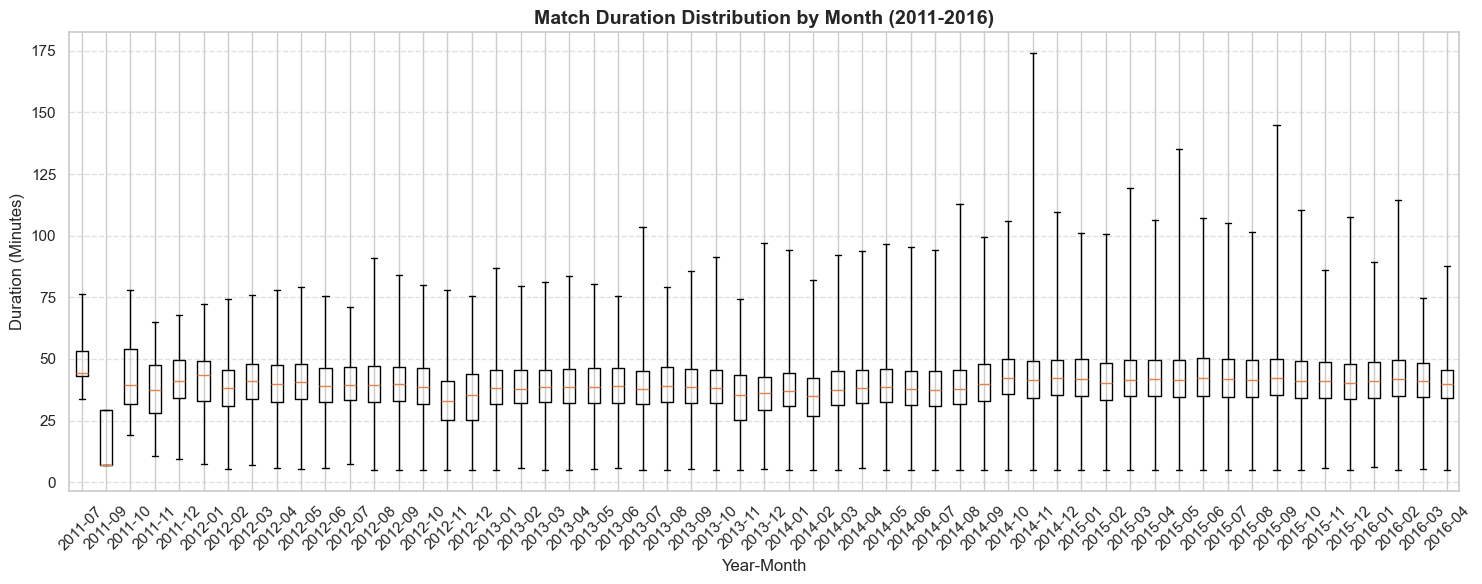

In [39]:
from pyspark.sql import functions as F
monthly_stats = df_p.groupBy("year", "month").agg(
    F.min("duration_min").alias("min_val"),
    F.expr("percentile_approx(duration_min, 0.25)").alias("q1"),
    F.expr("percentile_approx(duration_min, 0.5)").alias("median"),
    F.expr("percentile_approx(duration_min, 0.75)").alias("q3"),
    F.max("duration_min").alias("max_val")
).orderBy("year", "month").collect() 

box_data = []
for row in monthly_stats:
    box_data.append({
        'label': f"{row.year}-{row.month:02d}",
        'whislo': row.min_val,
        'q1': row.q1,
        'med': row.median,
        'q3': row.q3,
        'whishi': row.max_val,
        'fliers': []
    })

fig, ax = plt.subplots(figsize=(15, 6))
ax.bxp(box_data, showfliers=False)
ax.set_title("Match Duration Distribution by Month (2011-2016)", fontsize=14, fontweight='bold')
ax.set_ylabel("Duration (Minutes)")
ax.set_xlabel("Year-Month")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('opendota_processed/figures/figure1.png')
plt.show()



In [28]:
activity_trend = activity_trend.sort_values("month")

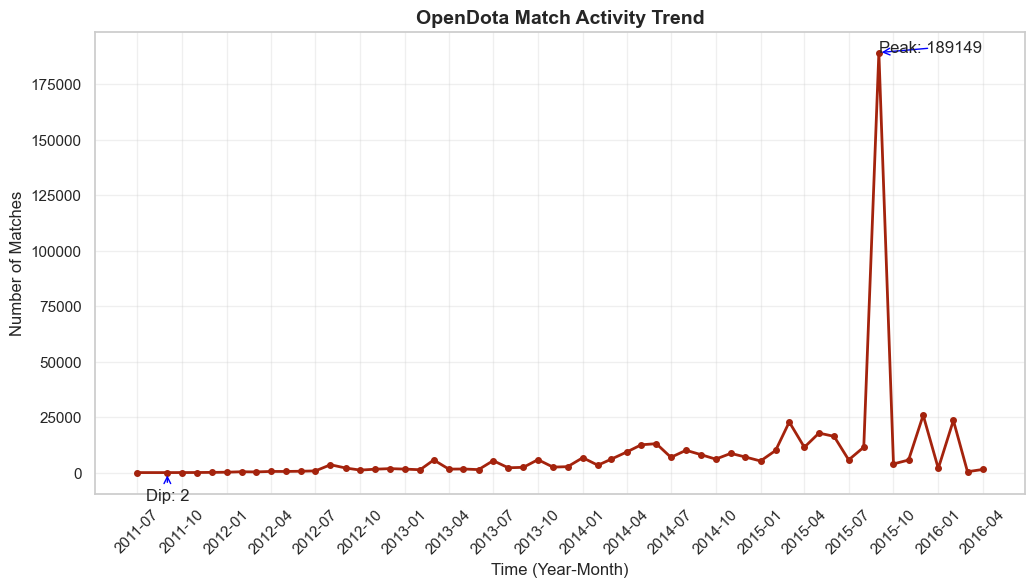

In [40]:
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, MonthLocator

activity_trend['date'] = pd.to_datetime({
    'year': activity_trend['year'],
    'month': activity_trend['month'],
    'day': 1
})
activity_trend = activity_trend.sort_values('date')
plt.figure(figsize=(12, 6))
plt.plot(activity_trend["date"], activity_trend["match_count"], 
         marker='o', color='#A4230D', linewidth=2, markersize=4, label='Match Volume')
max_row = activity_trend.loc[activity_trend['match_count'].idxmax()]
min_row = activity_trend.loc[activity_trend['match_count'].idxmin()]
plt.annotate(f'Peak: {int(max_row["match_count"])}', 
             xy=(max_row["date"], max_row["match_count"]),arrowprops=dict(arrowstyle='->', color='blue'))
plt.annotate(f'Dip: {int(min_row["match_count"])}', 
             xy=(min_row["date"], min_row["match_count"]),xytext=(0, -20), textcoords='offset points', ha='center',arrowprops=dict(arrowstyle='->', color='blue'))
plt.title("OpenDota Match Activity Trend", fontsize=14, fontweight='bold')
plt.xlabel("Time (Year-Month)")
plt.ylabel("Number of Matches")

plt.gca().xaxis.set_major_locator(MonthLocator(bymonth=[1, 4, 7, 10])) 
plt.gca().xaxis.set_major_formatter(DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.savefig('opendota_processed/figures/figure2.png')
plt.show()

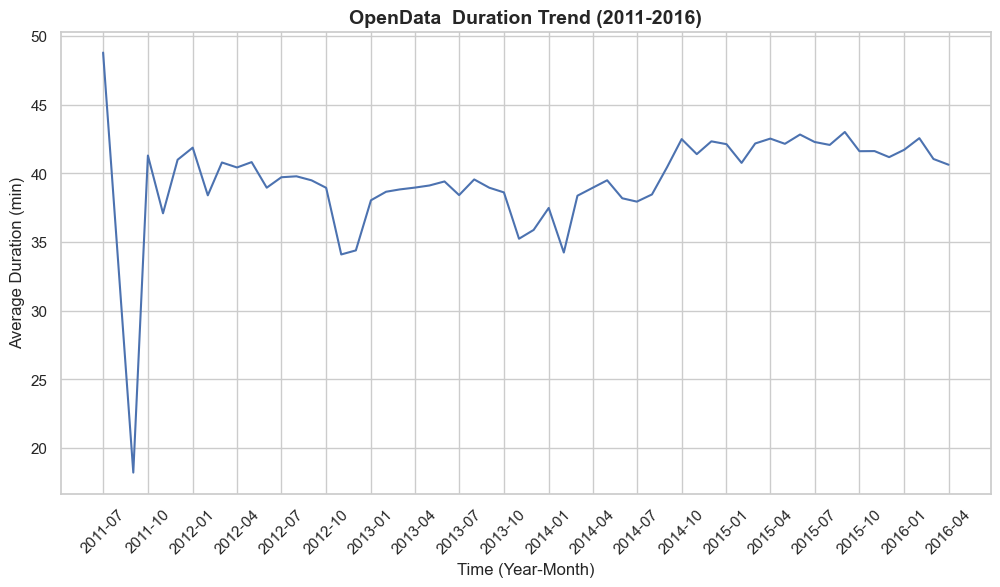

In [41]:
from matplotlib.dates import DateFormatter, MonthLocator
plt.figure(figsize=(12, 6))
x = pd.to_datetime(activity_trend['year'].combine(activity_trend['month'], lambda year, month: f'{year}-{month:02d}')).sort_values()
plt.plot(x,
         activity_trend['avg_duration'])
plt.title("OpenData  Duration Trend (2011-2016)", fontsize=14, fontweight='bold')
plt.xlabel("Time (Year-Month)")
plt.ylabel('Average Duration (min)')
plt.gca().xaxis.set_major_locator(
    MonthLocator(bymonth = [1, 4, 7, 10])
)

plt.gca().xaxis.set_major_formatter(
    DateFormatter("%Y-%m")
)
plt.xticks(rotation = 45)
plt.savefig('opendota_processed/figures/figure3.png')
plt.show()

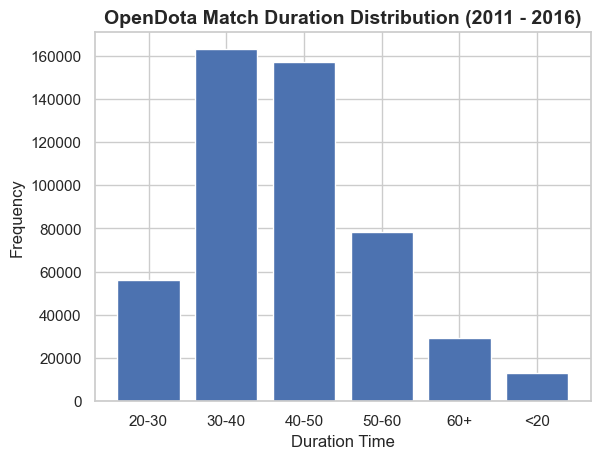

In [42]:
## 
plt.bar(play_time_dist['duration_bin'], play_time_dist["frequency"])
plt.title("OpenDota Match Duration Distribution (2011 - 2016)", fontsize=14, fontweight='bold')
plt.xlabel("Duration Time")
plt.ylabel("Frequency")
plt.savefig('opendota_processed/figures/figure4.png')
plt.show()

### Plotly Visualizations

In [43]:
import pandas as pd

def try_plotly():
    import plotly.express as px
    import plotly.graph_objects as go

    # 1) Activity over time
    fig1 = px.line(x=pd.to_datetime(activity_trend['year'].combine(activity_trend['month'], lambda year, month: f'{year}-{month:02d}')).sort_values(),
                   y=activity_trend['match_count'],
                   title="Interactive: Match Activity Over Time")
    fig1.show()

    # 2) Avg duration trend
    fig2 = px.line(x=pd.to_datetime(activity_trend['year'].combine(activity_trend['month'], lambda year, month: f'{year}-{month:02d}')).sort_values(),
                   y=activity_trend['avg_duration'], title="Interactive: Average Duration Trend")
    fig2.show()

    # 3) Duration bin bar
    fig3 = px.bar(play_time_dist, x="duration_bin", y="frequency", title="Interactive: Duration Distribution (Binned)")
    fig3.show()

try:
    try_plotly()
    print("✅ Plotly interactive charts rendered.")
except Exception as e:
    print("⚠️ Plotly not available (or failed to render). Falling back to table previews.")
    print(type(e).__name__, ":", e)

    print("\n--- activity_trend head ---")
    display(activity_trend.head(10))

    print("\n--- activity_trend head ---")
    display(activity_trend.head(10))

    print("\n--- play_time_dist ---")
    display(play_time_dist.head(10))


✅ Plotly interactive charts rendered.
